# Multinomial Logistic Regression: Hyperparameter Tuning Pipeline

Systematically tune hyperparameters and analyze their effects.

## Overview

This notebook:
1. Loads preprocessed TF-IDF features from `research_paper_classification.ipynb`
2. Implements multinomial logistic regression from scratch (numpy only)
3. Runs grid search over hyperparameter combinations
4. Tracks training/validation loss and accuracy per epoch
5. Visualizes convergence patterns and hyperparameter sensitivity
6. Generates heatmaps showing optimal hyperparameter regions

## Section 1: Setup and Utility Functions

Import libraries and define helper functions for data operations, preprocessing, and metrics calculation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")
print("✓ Random seed set to:", SEED)

✓ Libraries imported successfully
✓ Random seed set to: 42


In [2]:
# ============================================================================
# UTILITY FUNCTIONS: Data Loading and Preprocessing
# ============================================================================

def load_and_prepare_data(csv_path='data/combined_papers_cleaned.csv', 
                         test_size=0.2, val_size=0.2, random_state=SEED):
    """
    Load dataset and prepare train/val/test splits with TF-IDF vectorization.
    
    Parameters:
    -----------
    csv_path : str
        Path to cleaned dataset CSV
    test_size : float
        Proportion of data for test set (before split)
    val_size : float
        Proportion of trainval data for validation
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    Tuple of (X_train, X_val, X_test, y_train, y_val, y_test, 
              label_names, label_to_idx, idx_to_label, vectorizer)
    """
    print("Loading dataset...")
    df = pd.read_csv(csv_path)
    use_cols = ['label', 'title', 'abstract']
    df = df[use_cols].dropna().copy()
    print(f"  • Dataset shape: {df.shape}")
    
    # Encode labels
    label_names = sorted(df['label'].unique())
    label_to_idx = {l: i for i, l in enumerate(label_names)}
    idx_to_label = {i: l for l, i in label_to_idx.items()}
    y = np.array([label_to_idx[x] for x in df['label']])
    
    # Combine title and abstract
    X_text = (df['title'].fillna('') + ' ' + df['abstract'].fillna('')).values
    
    # First split: train+val vs test
    X_trainval_text, X_test_text, y_trainval, y_test = train_test_split(
        X_text, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Second split: train vs val
    X_train_text, X_val_text, y_train, y_val = train_test_split(
        X_trainval_text, y_trainval, test_size=val_size, random_state=random_state, stratify=y_trainval
    )
    
    # Fit vectorizer on train data only
    print("Vectorizing with TF-IDF...")
    vectorizer = TfidfVectorizer(stop_words='english', max_features=12000, 
                                min_df=3, ngram_range=(1, 2))
    X_train = vectorizer.fit_transform(X_train_text).toarray()
    X_val = vectorizer.transform(X_val_text).toarray()
    X_test = vectorizer.transform(X_test_text).toarray()
    
    print(f"  • Train shape: {X_train.shape}")
    print(f"  • Val shape:   {X_val.shape}")
    print(f"  • Test shape:  {X_test.shape}")
    print(f"  • Classes: {label_names}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, label_names, label_to_idx, idx_to_label, vectorizer


def create_one_hot(y, num_classes):
    """Convert label vector to one-hot encoding."""
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot


def softmax(logits):
    """
    Compute softmax probabilities numerically stable way.
    
    softmax(z_i) = exp(z_i) / sum(exp(z_j))
    
    Uses log-sum-exp trick: subtract max before exponential to prevent overflow.
    """
    z = logits - np.max(logits, axis=1, keepdims=True)  # Numerical stability
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)


def cross_entropy_loss(y_onehot, p, eps=1e-12):
    """
    Compute cross-entropy loss.
    
    L = -1/N * sum_i sum_k [y_ik * log(p_ik)]
    
    Parameters:
    -----------
    y_onehot : ndarray, shape (N, K)
        One-hot encoded labels
    p : ndarray, shape (N, K)
        Predicted probabilities (from softmax)
    eps : float
        Small epsilon to avoid log(0)
    
    Returns:
    --------
    float : Average cross-entropy loss
    """
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(np.sum(y_onehot * np.log(p), axis=1))


def compute_accuracy(y_true, y_pred):
    """Compute classification accuracy."""
    return float(np.mean(y_true == y_pred))


print("✓ Utility functions defined")

✓ Utility functions defined


## Section 2: Multinomial Logistic Regression Model

Implement the model from scratch with forward pass, loss computation, and gradient descent updates.

In [3]:
class MultinomialLogisticRegression:
    """
    Multinomial Logistic Regression from scratch using numpy.
    
    Model: p_k = softmax(W * x + b)_k
    
    Loss: L = cross_entropy(y, p) + 0.5 * lambda * ||W||_F^2
    
    Attributes:
    -----------
    W : ndarray, shape (n_features, n_classes)
        Weight matrix learned during training
    b : ndarray, shape (1, n_classes)
        Bias vector learned during training
    """
    
    def __init__(self, n_features, n_classes, random_state=SEED):
        """
        Initialize model parameters.
        
        Parameters:
        -----------
        n_features : int
            Number of input features
        n_classes : int
            Number of output classes
        random_state : int
            Seed for reproducible initialization
        """
        np.random.seed(random_state)
        # Small random initialization to break symmetry
        self.W = 0.01 * np.random.randn(n_features, n_classes)
        self.b = np.zeros((1, n_classes))
        self.n_features = n_features
        self.n_classes = n_classes
    
    def forward(self, X):
        """
        Forward pass: compute logits and probabilities.
        
        Parameters:
        -----------
        X : ndarray, shape (N, n_features)
            Input features
        
        Returns:
        --------
        logits : ndarray, shape (N, n_classes)
            Pre-softmax scores
        probs : ndarray, shape (N, n_classes)
            Softmax probabilities
        """
        logits = X @ self.W + self.b
        probs = softmax(logits)
        return logits, probs
    
    def compute_loss(self, X, y_onehot, lambda_reg=0.0):
        """
        Compute total loss = cross-entropy + L2 regularization.
        
        Parameters:
        -----------
        X : ndarray, shape (N, n_features)
            Input features
        y_onehot : ndarray, shape (N, n_classes)
            One-hot encoded labels
        lambda_reg : float
            L2 regularization strength
        
        Returns:
        --------
        loss : float
            Total loss value
        """
        _, probs = self.forward(X)
        ce_loss = cross_entropy_loss(y_onehot, probs)
        l2_penalty = 0.5 * lambda_reg * np.sum(self.W * self.W)
        return ce_loss + l2_penalty
    
    def backward(self, X, y_onehot, probs, lambda_reg=0.0):
        """
        Compute gradients via backpropagation.
        
        Gradient of softmax cross-entropy:
        dlog = (p - y) / N
        
        Gradients w.r.t. weights:
        dW = X^T @ dlog + lambda * W
        db = sum(dlog, axis=0)
        
        Parameters:
        -----------
        X : ndarray, shape (N, n_features)
            Input features
        y_onehot : ndarray, shape (N, n_classes)
            One-hot encoded labels
        probs : ndarray, shape (N, n_classes)
            Predicted probabilities from forward pass
        lambda_reg : float
            L2 regularization strength
        
        Returns:
        --------
        dW : ndarray, shape (n_features, n_classes)
            Gradient w.r.t. weights
        db : ndarray, shape (1, n_classes)
            Gradient w.r.t. bias
        """
        N = X.shape[0]
        dlog = (probs - y_onehot) / N
        dW = X.T @ dlog + lambda_reg * self.W
        db = dlog.sum(axis=0, keepdims=True)
        return dW, db
    
    def update_parameters(self, dW, db, learning_rate):
        """
        Update parameters via gradient descent.
        
        W := W - lr * dW
        b := b - lr * db
        
        Parameters:
        -----------
        dW : ndarray
            Gradient w.r.t. weights
        db : ndarray
            Gradient w.r.t. bias
        learning_rate : float
            Step size for gradient descent
        """
        self.W -= learning_rate * dW
        self.b -= learning_rate * db
    
    def predict_proba(self, X):
        """Get probability predictions."""
        _, probs = self.forward(X)
        return probs
    
    def predict(self, X):
        """Get class predictions."""
        probs = self.predict_proba(X)
        return probs.argmax(axis=1)


print("✓ MultinomialLogisticRegression class defined")

✓ MultinomialLogisticRegression class defined


## Section 3: Training and Evaluation Functions

Modular functions to train the model and evaluate on validation data.

In [4]:
def train_model(model, X_train, y_train, X_val, y_val, 
                learning_rate=0.01, lambda_reg=0.0, epochs=100, 
                batch_size=32, verbose=False, print_freq=10):
    """
    Train multinomial logistic regression with gradient descent.
    
    Performs mini-batch gradient descent, updating parameters after each batch.
    Tracks loss and accuracy on both training and validation sets each epoch.
    
    Parameters:
    -----------
    model : MultinomialLogisticRegression
        Model instance to train
    X_train : ndarray, shape (N_train, n_features)
        Training features
    y_train : ndarray, shape (N_train,)
        Training labels (integer class indices)
    X_val : ndarray, shape (N_val, n_features)
        Validation features
    y_val : ndarray, shape (N_val,)
        Validation labels
    learning_rate : float
        Learning rate (step size for gradient descent)
    lambda_reg : float
        L2 regularization strength
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for mini-batch gradient descent
    verbose : bool
        Whether to print progress
    print_freq : int
        Print progress every N epochs
    
    Returns:
    --------
    history : dict
        Training history with keys:
        - 'train_loss': list of training losses per epoch
        - 'val_loss': list of validation losses per epoch
        - 'train_acc': list of training accuracies per epoch
        - 'val_acc': list of validation accuracies per epoch
    """
    N_train = X_train.shape[0]
    y_train_onehot = create_one_hot(y_train, model.n_classes)
    y_val_onehot = create_one_hot(y_val, model.n_classes)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }
    
    indices = np.arange(N_train)
    
    for epoch in range(epochs):
        # Shuffle data for each epoch
        np.random.shuffle(indices)
        X_train_shuffled = X_train[indices]
        y_train_onehot_shuffled = y_train_onehot[indices]
        y_train_shuffled = y_train[indices]
        
        # Mini-batch updates
        for batch_start in range(0, N_train, batch_size):
            batch_end = min(batch_start + batch_size, N_train)
            X_batch = X_train_shuffled[batch_start:batch_end]
            y_batch_onehot = y_train_onehot_shuffled[batch_start:batch_end]
            
            # Forward pass
            _, probs = model.forward(X_batch)
            
            # Backward pass
            dW, db = model.backward(X_batch, y_batch_onehot, probs, lambda_reg)
            
            # Update parameters
            model.update_parameters(dW, db, learning_rate)
        
        # Compute metrics on full training and validation sets
        train_loss = model.compute_loss(X_train, y_train_onehot, lambda_reg)
        val_loss = model.compute_loss(X_val, y_val_onehot, lambda_reg)
        
        train_acc = compute_accuracy(y_train, model.predict(X_train))
        val_acc = compute_accuracy(y_val, model.predict(X_val))
        
        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))
        history['train_acc'].append(float(train_acc))
        history['val_acc'].append(float(val_acc))
        
        if verbose and (epoch == 0 or (epoch + 1) % print_freq == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch+1:4d} | "
                  f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
                  f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")
    
    return history


def evaluate_model(model, X_test, y_test):
    """
    Evaluate model on test set.
    
    Parameters:
    -----------
    model : MultinomialLogisticRegression
        Trained model
    X_test : ndarray, shape (N_test, n_features)
        Test features
    y_test : ndarray, shape (N_test,)
        Test labels
    
    Returns:
    --------
    metrics : dict
        Dictionary with keys:
        - 'accuracy': Classification accuracy
        - 'predictions': Model predictions
        - 'probabilities': Predicted probabilities
    """
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)
    accuracy = compute_accuracy(y_test, y_pred)
    
    return {
        'accuracy': accuracy,
        'predictions': y_pred,
        'probabilities': probs
    }


print("✓ Train and evaluate functions defined")

✓ Train and evaluate functions defined


## Section 4: Grid Search Experiment Framework

Implement high-level experiment runner and grid search over hyperparameter combinations.

In [5]:
def run_experiment(X_train, y_train, X_val, y_val, X_test, y_test,
                   learning_rate=0.01, lambda_reg=0.0, epochs=100, 
                   batch_size=32, n_classes=3, verbose=False):
    """
    Run a single experiment with given hyperparameters.
    
    This function initializes a fresh model, trains it, and returns 
    all metrics and training history in a structured results dictionary.
    
    Parameters:
    -----------
    X_train, y_train : ndarray
        Training data
    X_val, y_val : ndarray
        Validation data
    X_test, y_test : ndarray
        Test data
    learning_rate : float
        Learning rate for gradient descent
    lambda_reg : float
        L2 regularization strength
    epochs : int
        Number of training epochs
    batch_size : int
        Mini-batch size
    n_classes : int
        Number of classes
    verbose : bool
        Whether to print training progress
    
    Returns:
    --------
    results : dict
        Results dictionary containing:
        - 'hyperparams': dict of hyperparameter values used
        - 'history': training history (loss/accuracy per epoch)
        - 'val_acc_final': final validation accuracy
        - 'train_acc_final': final training accuracy
        - 'train_loss': list of training losses per epoch
        - 'val_loss': list of validation losses per epoch
    """
    # Initialize model
    n_features = X_train.shape[1]
    model = MultinomialLogisticRegression(n_features, n_classes)
    
    # Train model
    history = train_model(
        model, X_train, y_train, X_val, y_val,
        learning_rate=learning_rate,
        lambda_reg=lambda_reg,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        print_freq=max(1, epochs // 5)
    )
    
    # Extract final metrics
    val_acc_final = history['val_acc'][-1]
    train_acc_final = history['train_acc'][-1]
    
    results = {
        'hyperparams': {
            'learning_rate': learning_rate,
            'lambda_reg': lambda_reg,
            'epochs': epochs,
            'batch_size': batch_size
        },
        'history': history,
        'val_acc_final': val_acc_final,
        'train_acc_final': train_acc_final,
        'train_loss': history['train_loss'],
        'val_loss': history['val_loss'],
        'train_acc_per_epoch': history['train_acc'],
        'val_acc_per_epoch': history['val_acc']
    }
    
    return results


def grid_search(X_train, y_train, X_val, y_val, X_test, y_test, n_classes=3,
                learning_rates=[0.001, 0.01, 0.1], 
                lambda_regs=[0.0, 0.01, 0.1],
                batch_sizes=[32, 64],
                epochs_list=[100],
                verbose=False):
    """
    Perform grid search over hyperparameter combinations.
    
    Systematically tests all combinations of hyperparameters and stores
    results in a structured format for analysis and visualization.
    
    Parameters:
    -----------
    X_train, y_train, X_val, y_val, X_test, y_test : ndarray
        Dataset splits
    n_classes : int
        Number of classes
    learning_rates : list
        List of learning rates to try
    lambda_regs : list
        List of L2 regularization strengths to try
    batch_sizes : list
        List of batch sizes to try
    epochs_list : list
        List of epoch counts to try
    verbose : bool
        Whether to print detailed progress
    
    Returns:
    --------
    all_results : list of dict
        Each dict contains results from one experiment run
    results_df : pd.DataFrame
        Summary of all experiments with columns:
        - lr, lambda_reg, batch_size, epochs (hyperparameters)
        - val_acc_final, train_acc_final (accuracy metrics)
    """
    total_configs = (len(learning_rates) * len(lambda_regs) * 
                    len(batch_sizes) * len(epochs_list))
    
    print(f"\n{'='*70}")
    print(f"GRID SEARCH: Testing {total_configs} hyperparameter combinations")
    print(f"{'='*70}\n")
    
    all_results = []
    config_num = 0
    
    for lr in learning_rates:
        for lambda_reg in lambda_regs:
            for batch_size in batch_sizes:
                for epochs in epochs_list:
                    config_num += 1
                    
                    print(f"[{config_num:3d}/{total_configs}] "
                          f"lr={lr:.4f} | λ={lambda_reg:.4f} | "
                          f"batch={batch_size:2d} | epochs={epochs:3d}  ... ", 
                          end='', flush=True)
                    
                    # Run experiment
                    results = run_experiment(
                        X_train, y_train, X_val, y_val, X_test, y_test,
                        learning_rate=lr,
                        lambda_reg=lambda_reg,
                        epochs=epochs,
                        batch_size=batch_size,
                        n_classes=n_classes,
                        verbose=False
                    )
                    
                    all_results.append(results)
                    
                    val_acc = results['val_acc_final']
                    train_acc = results['train_acc_final']
                    print(f"val_acc={val_acc:.4f} | train_acc={train_acc:.4f}")
    
    # Convert to DataFrame for easy analysis
    summary_data = []
    for r in all_results:
        hp = r['hyperparams']
        summary_data.append({
            'lr': hp['learning_rate'],
            'lambda_reg': hp['lambda_reg'],
            'batch_size': hp['batch_size'],
            'epochs': hp['epochs'],
            'val_acc_final': r['val_acc_final'],
            'train_acc_final': r['train_acc_final'],
        })
    
    results_df = pd.DataFrame(summary_data)
    
    print(f"\n{'='*70}")
    print(f"GRID SEARCH COMPLETE")
    print(f"{'='*70}\n")
    
    return all_results, results_df


print("✓ Experiment and grid search functions defined")

✓ Experiment and grid search functions defined


## Section 5: Load Data and Run Hyperparameter Experiments

Load preprocessed data and execute grid search over hyperparameter space.

In [6]:
# Load and prepare dataset
X_train, X_val, X_test, y_train, y_val, y_test, label_names, label_to_idx, idx_to_label, vectorizer = load_and_prepare_data()
n_classes = len(label_names)
n_features = X_train.shape[1]

print(f"\n✓ Data preparation complete")
print(f"  • Number of features: {n_features}")
print(f"  • Number of classes: {n_classes}")
print(f"  • Class names: {label_names}")

Loading dataset...
  • Dataset shape: (2855, 3)
Vectorizing with TF-IDF...
  • Train shape: (1827, 12000)
  • Val shape:   (457, 12000)
  • Test shape:  (571, 12000)
  • Classes: ['APPLIED', 'SURVEY', 'THEORETICAL']

✓ Data preparation complete
  • Number of features: 12000
  • Number of classes: 3
  • Class names: ['APPLIED', 'SURVEY', 'THEORETICAL']


In [13]:
# ============================================================================
# EXECUTE FOCUSED HYPERPARAMETER SEARCH (around your best baseline)
# ============================================================================
# Baseline that worked well for you:
#   epochs=1000, lr=0.5, l2=1e-4
#
# To stay faithful to research_paper_classification.ipynb training behavior,
# we use FULL-BATCH gradient descent (batch_size = number of training samples).

baseline_lr = 0.5
baseline_l2 = 1e-4
baseline_epochs = 1000
full_batch_size = X_train.shape[0]  # Same update style as the original notebook

print("\nFocused tuning baseline:")
print(f"  • lr={baseline_lr}")
print(f"  • l2={baseline_l2}")
print(f"  • epochs={baseline_epochs}")
print(f"  • batch_size={full_batch_size} (full-batch)")

# ---------------------------------------------------------------------------
# Stage 1 (coarse local search): quick sweep near baseline, low epoch budget
# ---------------------------------------------------------------------------
stage1_learning_rates = [0.45, 0.50, 0.55]
stage1_lambda_regs = [5e-5, 1e-4, 2e-4]
stage1_epochs = [120]  # quick ranking pass

print("\n[Stage 1] Coarse local sweep")
print(f"  • learning_rates={stage1_learning_rates}")
print(f"  • lambda_regs={stage1_lambda_regs}")
print(f"  • epochs={stage1_epochs}")

stage1_results, stage1_df = grid_search(
    X_train, y_train, X_val, y_val, X_test, y_test,
    n_classes=n_classes,
    learning_rates=stage1_learning_rates,
    lambda_regs=stage1_lambda_regs,
    batch_sizes=[full_batch_size],
    epochs_list=stage1_epochs,
    verbose=False
)

print("\nTop Stage-1 configs by validation accuracy:")
display(stage1_df.sort_values('val_acc_final', ascending=False))

# ---------------------------------------------------------------------------
# Stage 2 (confirmation): rerun top configs at the full training budget
# ---------------------------------------------------------------------------
num_top_for_stage2 = 3
top_stage1 = stage1_df.sort_values('val_acc_final', ascending=False).head(num_top_for_stage2)

print(f"\n[Stage 2] Re-evaluate top {num_top_for_stage2} configs at epochs={baseline_epochs}")

all_results = []
summary_rows = []

for i, (_, row) in enumerate(top_stage1.iterrows(), start=1):
    lr = float(row['lr'])
    lambda_reg = float(row['lambda_reg'])

    print(
        f"[{i}/{num_top_for_stage2}] "
        f"lr={lr:.4f} | λ={lambda_reg:.6f} | "
        f"batch={full_batch_size} | epochs={baseline_epochs} ... ",
        end='', flush=True
    )

    result = run_experiment(
        X_train, y_train, X_val, y_val, X_test, y_test,
        learning_rate=lr,
        lambda_reg=lambda_reg,
        epochs=baseline_epochs,
        batch_size=full_batch_size,
        n_classes=n_classes,
        verbose=False
    )

    all_results.append(result)

    summary_rows.append({
        'lr': lr,
        'lambda_reg': lambda_reg,
        'batch_size': full_batch_size,
        'epochs': baseline_epochs,
        'val_acc_final': result['val_acc_final'],
        'train_acc_final': result['train_acc_final']
    })

    print(f"val_acc={result['val_acc_final']:.4f} | train_acc={result['train_acc_final']:.4f}")

results_df = pd.DataFrame(summary_rows).sort_values('val_acc_final', ascending=False).reset_index(drop=True)

print("\nFinal focused-search ranking (1000 epochs):")
display(results_df)

best_cfg = results_df.iloc[0]
print("Best configuration found near your baseline:")
print(
    f"  lr={best_cfg['lr']:.6f}, "
    f"l2={best_cfg['lambda_reg']:.6f}, "
    f"batch_size={int(best_cfg['batch_size'])}, "
    f"epochs={int(best_cfg['epochs'])}, "
    f"val_acc={best_cfg['val_acc_final']:.4f}"
)



Focused tuning baseline:
  • lr=0.5
  • l2=0.0001
  • epochs=1000
  • batch_size=1827 (full-batch)

[Stage 1] Coarse local sweep
  • learning_rates=[0.45, 0.5, 0.55]
  • lambda_regs=[5e-05, 0.0001, 0.0002]
  • epochs=[120]

GRID SEARCH: Testing 9 hyperparameter combinations

[  1/9] lr=0.4500 | λ=0.0001 | batch=1827 | epochs=120  ... val_acc=0.9365 | train_acc=0.9371
[  2/9] lr=0.4500 | λ=0.0001 | batch=1827 | epochs=120  ... val_acc=0.9365 | train_acc=0.9371
[  3/9] lr=0.4500 | λ=0.0002 | batch=1827 | epochs=120  ... val_acc=0.9365 | train_acc=0.9371
[  4/9] lr=0.5000 | λ=0.0001 | batch=1827 | epochs=120  ... val_acc=0.9453 | train_acc=0.9414
[  5/9] lr=0.5000 | λ=0.0001 | batch=1827 | epochs=120  ... val_acc=0.9453 | train_acc=0.9414
[  6/9] lr=0.5000 | λ=0.0002 | batch=1827 | epochs=120  ... val_acc=0.9453 | train_acc=0.9414
[  7/9] lr=0.5500 | λ=0.0001 | batch=1827 | epochs=120  ... val_acc=0.9453 | train_acc=0.9464
[  8/9] lr=0.5500 | λ=0.0001 | batch=1827 | epochs=120  ... val_a

,lr,lambda_reg,batch_size,epochs,val_acc_final,train_acc_final
4,0.50,0.00010,1827,120,0.945295,0.941434
7,0.55,0.00010,1827,120,0.945295,0.946360
3,0.50,0.00005,1827,120,0.945295,0.941434
6,0.55,0.00005,1827,120,0.945295,0.946360
5,0.50,0.00020,1827,120,0.945295,0.941434
8,0.55,0.00020,1827,120,0.945295,0.946360
0,0.45,0.00005,1827,120,0.936543,0.937055
1,0.45,0.00010,1827,120,0.936543,0.937055
2,0.45,0.00020,1827,120,0.936543,0.937055



[Stage 2] Re-evaluate top 3 configs at epochs=1000
[1/3] lr=0.5000 | λ=0.000100 | batch=1827 | epochs=1000 ... val_acc=0.9737 | train_acc=0.9743
[2/3] lr=0.5500 | λ=0.000100 | batch=1827 | epochs=1000 ... val_acc=0.9737 | train_acc=0.9765
[3/3] lr=0.5000 | λ=0.000050 | batch=1827 | epochs=1000 ... val_acc=0.9737 | train_acc=0.9743

Final focused-search ranking (1000 epochs):


,lr,lambda_reg,batch_size,epochs,val_acc_final,train_acc_final
0,0.50,0.00010,1827,1000,0.973742,0.974275
1,0.55,0.00010,1827,1000,0.973742,0.976464
2,0.50,0.00005,1827,1000,0.973742,0.974275


Best configuration found near your baseline:
  lr=0.500000, l2=0.000100, batch_size=1827, epochs=1000, val_acc=0.9737


## Section 6: Visualize Experiment Results

Create heatmaps and plots showing how different hyperparameter combinations affect validation accuracy.

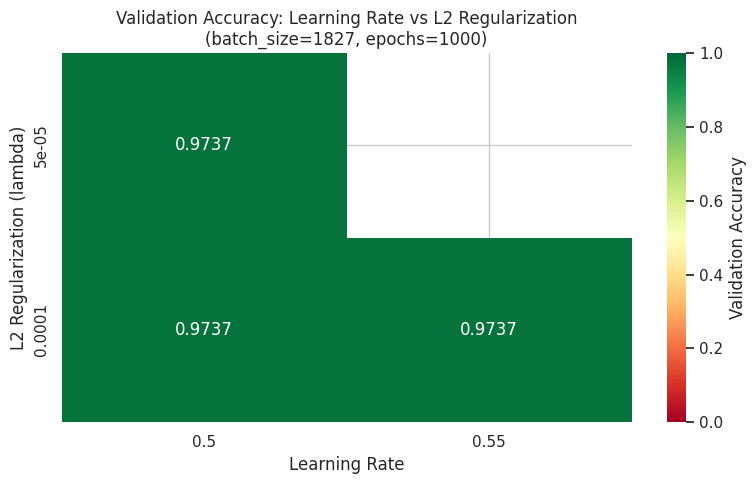


✓ Heatmap: Learning Rate vs Regularization


In [16]:
# ============================================================================
# VISUALIZATION 1: Heatmap - Learning Rate vs L2 Regularization
# ============================================================================
# Uses the CURRENT results_df produced by the latest search run.

if results_df.empty:
    print("No results available. Run the search cell first.")
else:
    # Pick one (batch_size, epochs) slice for a clean 2D heatmap.
    # This avoids relying on stale global variables from older runs.
    mode_batch = int(results_df['batch_size'].mode().iloc[0])
    mode_epochs = int(results_df['epochs'].mode().iloc[0])

    filtered_df = results_df[
        (results_df['batch_size'] == mode_batch) &
        (results_df['epochs'] == mode_epochs)
    ].copy()

    heatmap_data = filtered_df.pivot_table(
        values='val_acc_final',
        index='lambda_reg',
        columns='lr',
        aggfunc='mean'
    )

    if heatmap_data.empty:
        print("No data for selected slice. Showing all results without slicing.")
        heatmap_data = results_df.pivot_table(
            values='val_acc_final',
            index='lambda_reg',
            columns='lr',
            aggfunc='mean'
        )

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.4f',
        cmap='RdYlGn',
        cbar_kws={'label': 'Validation Accuracy'},
        vmin=0,
        vmax=1
    )
    plt.title(
        f'Validation Accuracy: Learning Rate vs L2 Regularization\n'
        f'(batch_size={mode_batch}, epochs={mode_epochs})'
    )
    plt.xlabel('Learning Rate')
    plt.ylabel('L2 Regularization (lambda)')
    plt.tight_layout()
    plt.show()

    print("\n✓ Heatmap: Learning Rate vs Regularization")

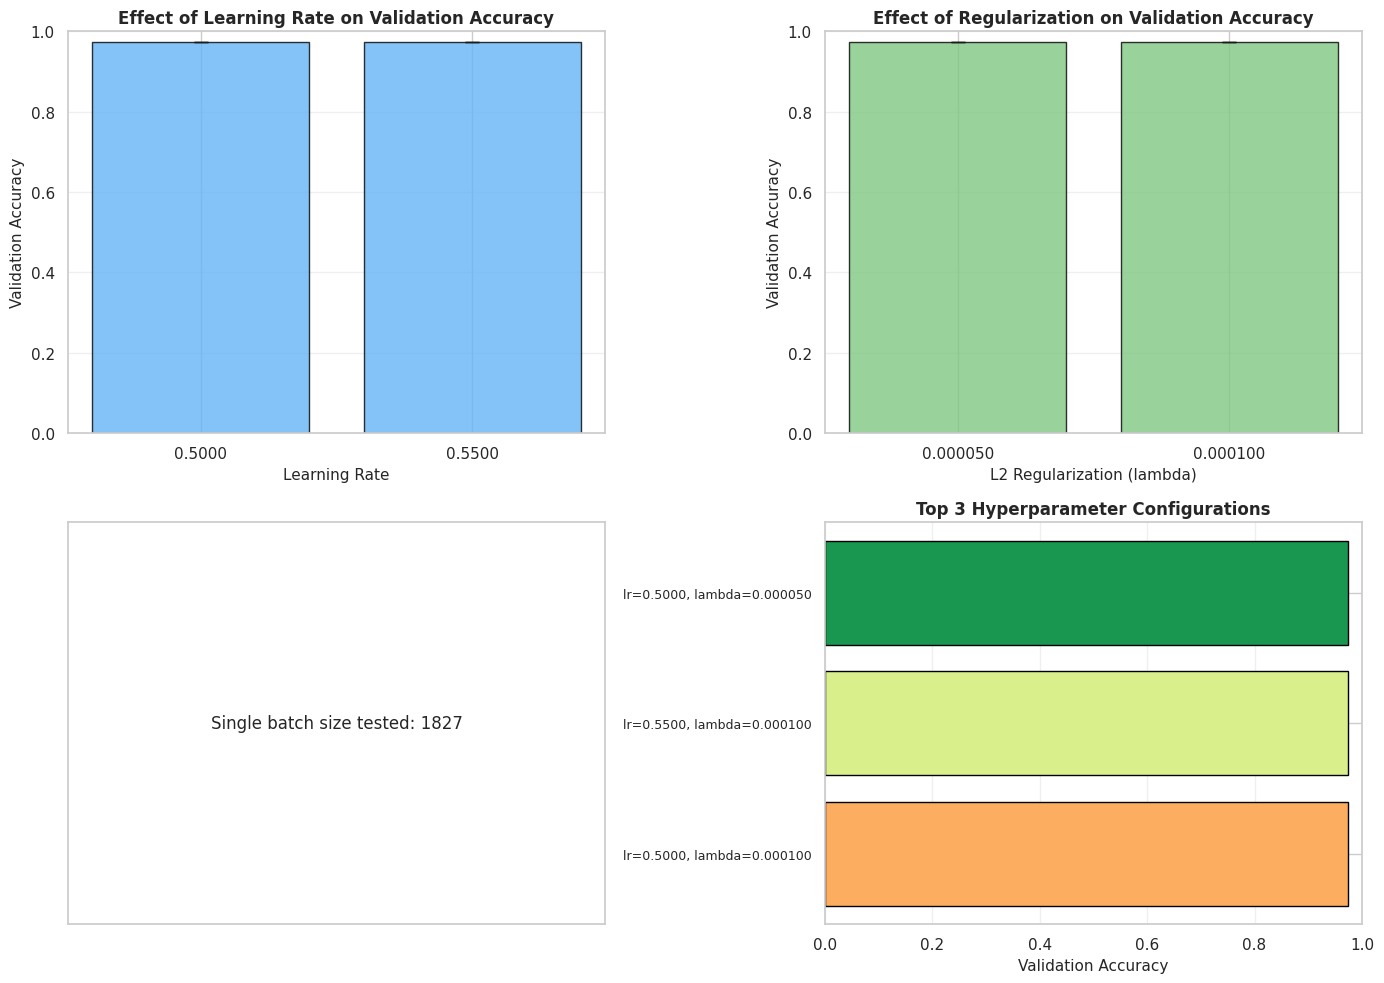

✓ Individual hyperparameter effects visualized


In [17]:
# ============================================================================
# VISUALIZATION 2: Individual Hyperparameter Effects
# ============================================================================
# Analyze how each hyperparameter independently affects validation accuracy.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Learning Rate Effect
lr_effect = results_df.groupby('lr', as_index=True)['val_acc_final'].agg(['mean', 'std'])
ax = axes[0, 0]
ax.bar(
    range(len(lr_effect)),
    lr_effect['mean'],
    yerr=lr_effect['std'].fillna(0.0),
    capsize=5,
    color='#64b5f6',
    alpha=0.8,
    edgecolor='black'
)
ax.set_xticks(range(len(lr_effect)))
ax.set_xticklabels([f'{x:.4f}' for x in lr_effect.index])
ax.set_xlabel('Learning Rate', fontsize=11)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.set_title('Effect of Learning Rate on Validation Accuracy', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

# Plot 2: L2 Regularization Effect
reg_effect = results_df.groupby('lambda_reg', as_index=True)['val_acc_final'].agg(['mean', 'std'])
ax = axes[0, 1]
ax.bar(
    range(len(reg_effect)),
    reg_effect['mean'],
    yerr=reg_effect['std'].fillna(0.0),
    capsize=5,
    color='#81c784',
    alpha=0.8,
    edgecolor='black'
)
ax.set_xticks(range(len(reg_effect)))
ax.set_xticklabels([f'{x:.6f}' for x in reg_effect.index])
ax.set_xlabel('L2 Regularization (lambda)', fontsize=11)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.set_title('Effect of Regularization on Validation Accuracy', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

# Plot 3: Batch Size Effect
if results_df['batch_size'].nunique() > 1:
    batch_effect = results_df.groupby('batch_size', as_index=True)['val_acc_final'].agg(['mean', 'std'])
    ax = axes[1, 0]
    ax.bar(
        range(len(batch_effect)),
        batch_effect['mean'],
        yerr=batch_effect['std'].fillna(0.0),
        capsize=5,
        color='#ffb74d',
        alpha=0.8,
        edgecolor='black'
    )
    ax.set_xticks(range(len(batch_effect)))
    ax.set_xticklabels([str(int(x)) for x in batch_effect.index])
    ax.set_xlabel('Batch Size', fontsize=11)
    ax.set_ylabel('Validation Accuracy', fontsize=11)
    ax.set_title('Effect of Batch Size on Validation Accuracy', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1])
else:
    axes[1, 0].text(
        0.5,
        0.5,
        f"Single batch size tested: {int(results_df['batch_size'].iloc[0])}",
        ha='center',
        va='center',
        transform=axes[1, 0].transAxes
    )
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])

# Plot 4: Top configurations
ax = axes[1, 1]
top_n = min(10, len(results_df))
top_results = results_df.nlargest(top_n, 'val_acc_final').reset_index(drop=True)
labels = [
    f"lr={r['lr']:.4f}, lambda={r['lambda_reg']:.6f}"
    for _, r in top_results.iterrows()
]
colors_grad = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_results)))
ax.barh(range(len(top_results)), top_results['val_acc_final'], color=colors_grad, edgecolor='black')
ax.set_yticks(range(len(top_results)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Validation Accuracy', fontsize=11)
ax.set_title(f'Top {top_n} Hyperparameter Configurations', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Individual hyperparameter effects visualized")

## Section 7: Analyze Learning Curves and Convergence

Plot training vs validation loss curves to understand convergence behavior and overfitting patterns.

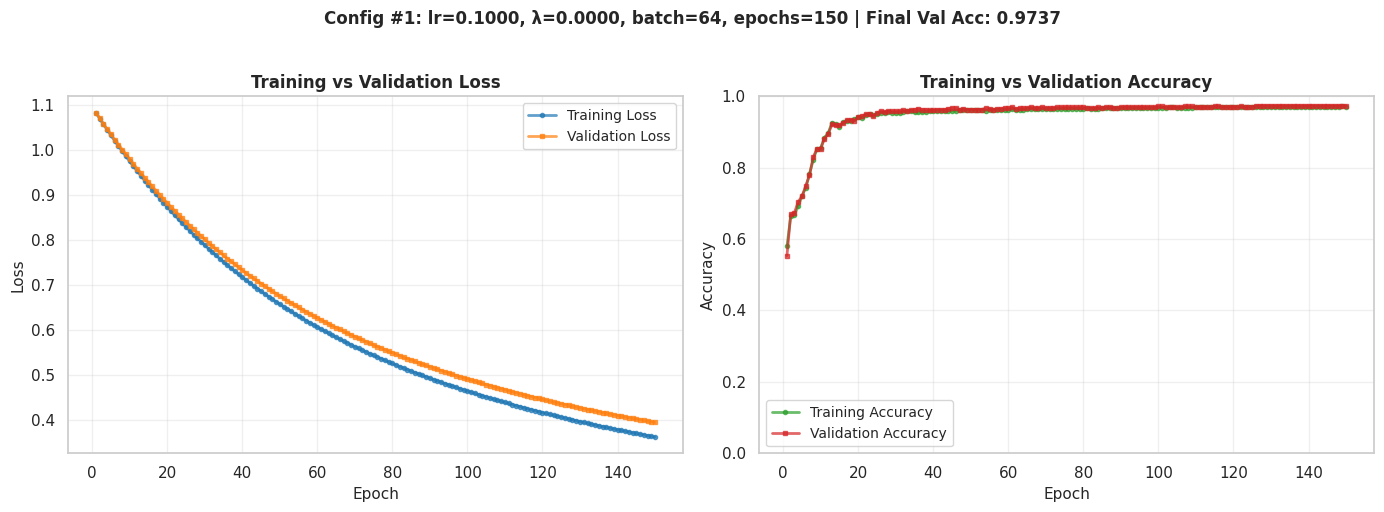

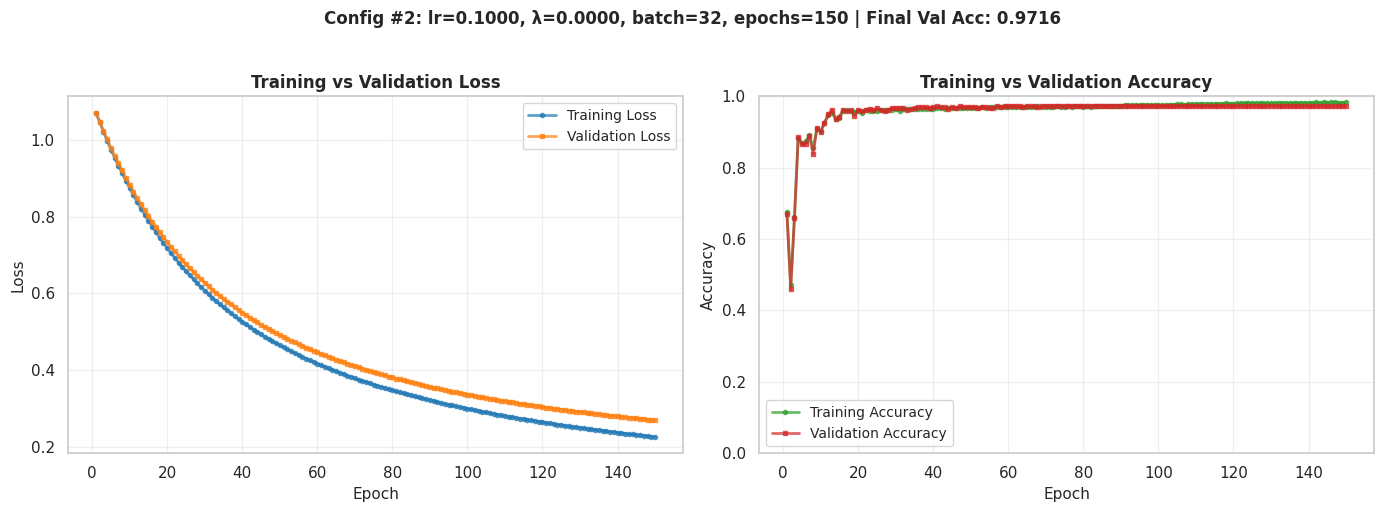

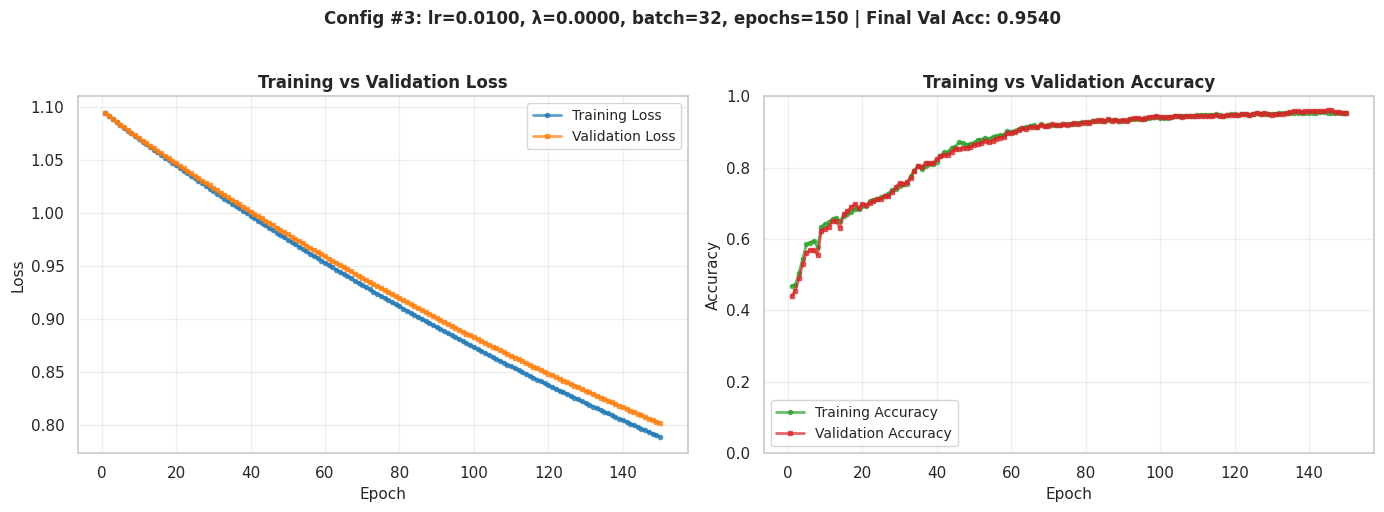

✓ Learning curves for top 3 configurations plotted


In [10]:
# ============================================================================
# LEARNING CURVES: Selected Hyperparameter Combinations
# ============================================================================
#
# Plots show:
# • LOSS CURVES (left): How training and validation loss change over epochs
#   - Lower loss = better optimization
#   - Gap between train/val = overfitting indicator
# • ACCURACY CURVES (right): How classification accuracy improves
#
# Interpretation Guide:
# - Steep descent: Fast early learning (high learning rate)
# - Plateau: Model has converged (reached optimization limit)
# - Diverging curves: Overfitting (validation rises while training falls)
# - Noise: High learning rate or insufficient regularization
#

# Select top 3 configurations to visualize
top_configs = results_df.nlargest(3, 'val_acc_final')

for idx, (_, config) in enumerate(top_configs.iterrows(), 1):
    # Find the corresponding experiment result
    matching_result = None
    for r in all_results:
        hp = r['hyperparams']
        if (hp['learning_rate'] == config['lr'] and 
            hp['lambda_reg'] == config['lambda_reg'] and
            hp['batch_size'] == int(config['batch_size']) and
            hp['epochs'] == int(config['epochs'])):
            matching_result = r
            break
    
    if matching_result is None:
        continue
    
    history = matching_result['history']
    epochs_range = np.arange(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    ax = axes[0]
    ax.plot(epochs_range, history['train_loss'], label='Training Loss', 
            linewidth=2, color='#1f77b4', marker='o', markersize=3, alpha=0.7)
    ax.plot(epochs_range, history['val_loss'], label='Validation Loss', 
            linewidth=2, color='#ff7f0e', marker='s', markersize=3, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    # Accuracy curves
    ax = axes[1]
    ax.plot(epochs_range, history['train_acc'], label='Training Accuracy', 
            linewidth=2, color='#2ca02c', marker='o', markersize=3, alpha=0.7)
    ax.plot(epochs_range, history['val_acc'], label='Validation Accuracy', 
            linewidth=2, color='#d62728', marker='s', markersize=3, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title('Training vs Validation Accuracy', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])
    
    # Title with hyperparameter values
    hp = matching_result['hyperparams']
    fig.suptitle(
        f"Config #{idx}: lr={hp['learning_rate']:.4f}, λ={hp['lambda_reg']:.4f}, "
        f"batch={hp['batch_size']}, epochs={hp['epochs']} | "
        f"Final Val Acc: {config['val_acc_final']:.4f}",
        fontsize=12, fontweight='bold', y=1.02
    )
    
    plt.tight_layout()
    plt.show()


print("✓ Learning curves for top 3 configurations plotted")